## 1. Prep

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
sns.set_theme(style="whitegrid")

## 2. Load and clean

In [3]:
file_path = "nbaallelo.csv"

df = pd.read_csv(file_path)
df.head()

df["date_game"] = pd.to_datetime(df["date_game"], errors="coerce")

df = (
    df.sort_values(["date_game", "gameorder", "game_id"])
      .reset_index(drop=True)
)

if "_iscopy" in df.columns:
    df = df.drop(columns="_iscopy")

keep_cols = [
    "gameorder", "game_id", "lg_id", "year_id", "date_game", "seasongame",
    "is_playoffs", "team_id", "fran_id", "pts", "elo_i", "elo_n",
    "win_equiv", "opp_id", "opp_fran", "opp_pts", "opp_elo_i", "opp_elo_n",
    "game_location", "game_result", "forecast", "notes"
]
keep_cols = [c for c in keep_cols if c in df.columns]
df = df[keep_cols].copy()

print("Shape:", df.shape)
print("Year range:", df["year_id"].min(), "to", df["year_id"].max())
print("Missing dates:", df["date_game"].isna().sum())
print("\nRows per game_id:")
print(df.groupby("game_id").size().value_counts().sort_index())

df.head()

Shape: (126314, 22)
Year range: 1947 to 2015
Missing dates: 0

Rows per game_id:
2    63157
Name: count, dtype: int64


,gameorder,game_id,lg_id,year_id,date_game,seasongame,is_playoffs,team_id,fran_id,pts,...,win_equiv,opp_id,opp_fran,opp_pts,opp_elo_i,opp_elo_n,game_location,game_result,forecast,notes
0,1,194611010TRH,NBA,1947,1946-11-01,1,0,TRH,Huskies,66,...,40.294830,NYK,Knicks,68,1300.0000,1306.7233,H,L,0.640065,NaN
1,1,194611010TRH,NBA,1947,1946-11-01,1,0,NYK,Knicks,68,...,41.705170,TRH,Huskies,66,1300.0000,1293.2767,A,W,0.359935,NaN
2,2,194611020CHS,NBA,1947,1946-11-02,1,0,CHS,Stags,63,...,42.012257,NYK,Knicks,47,1306.7233,1297.0712,H,W,0.631101,NaN
3,2,194611020CHS,NBA,1947,1946-11-02,2,0,NYK,Knicks,47,...,40.692783,CHS,Stags,63,1300.0000,1309.6521,A,L,0.368899,NaN
4,3,194611020DTF,NBA,1947,1946-11-02,1,0,DTF,Falcons,33,...,38.864048,WSC,Capitols,50,1300.0000,1320.3811,H,L,0.640065,NaN


## 3. Label creation, pregame features

In [4]:
REGULAR_SEASON_ONLY = False

if REGULAR_SEASON_ONLY:
    df = df[df["is_playoffs"] == 0].copy()

UPSET_THRESHOLD = 0.40

df["win"] = (df["game_result"] == "W").astype(int)
df["upset"] = ((df["forecast"] <= UPSET_THRESHOLD) & (df["win"] == 1)).astype(int)

df["elo_gap"] = df["elo_i"] - df["opp_elo_i"]
df["is_home"] = (df["game_location"] == "H").astype(int)
df["is_away"] = (df["game_location"] == "A").astype(int)
df["is_neutral"] = (df["game_location"] == "N").astype(int)

df["point_diff"] = df["pts"] - df["opp_pts"]
df["elo_delta"] = df["elo_n"] - df["elo_i"]

# Franchise-specific chronological ordering
df = (
    df.sort_values(["fran_id", "date_game", "gameorder", "game_id"])
      .reset_index(drop=True)
)

df[["date_game", "fran_id", "team_id", "opp_id", "forecast", "win", "upset", "elo_gap"]].head()

,date_game,fran_id,team_id,opp_id,forecast,win,upset,elo_gap
0,1947-11-12,Baltimore,BLB,WSC,0.282326,0,0,-62.0703
1,1947-11-13,Baltimore,BLB,BOS,0.784507,1,0,124.4652
2,1947-11-15,Baltimore,BLB,CHS,0.333132,1,1,-20.5695
3,1947-11-20,Baltimore,BLB,NYK,0.702461,1,0,49.2312
4,1947-11-21,Baltimore,BLB,BOS,0.550836,1,0,135.4471


## 4. Time-series features within each franchise

In [5]:
def add_team_history_features(data, group_col="fran_id"):
    data = data.copy()
    g = data.groupby(group_col, group_keys=False)

    data["prior_games_count"] = g.cumcount()

    # Recent-form features: last 10 games
    data["win_rolling_10"] = g["win"].transform(
        lambda s: s.shift(1).rolling(10, min_periods=1).mean()
    )

    data["pointdiff_rolling_10"] = g["point_diff"].transform(
        lambda s: s.shift(1).rolling(10, min_periods=1).mean()
    )

    data["pointdiff_std_10"] = g["point_diff"].transform(
        lambda s: s.shift(1).rolling(10, min_periods=2).std()
    )

    data["elo_delta_rolling_10"] = g["elo_delta"].transform(
        lambda s: s.shift(1).rolling(10, min_periods=1).mean()
    )

    data["opp_elo_rolling_10"] = g["opp_elo_i"].transform(
        lambda s: s.shift(1).rolling(10, min_periods=1).mean()
    )

    # Full-history features: expanding prior history
    data["win_expanding"] = g["win"].transform(
        lambda s: s.shift(1).expanding(min_periods=1).mean()
    )

    data["pointdiff_expanding"] = g["point_diff"].transform(
        lambda s: s.shift(1).expanding(min_periods=1).mean()
    )

    data["pointdiff_std_expanding"] = g["point_diff"].transform(
        lambda s: s.shift(1).expanding(min_periods=2).std()
    )

    data["elo_delta_expanding"] = g["elo_delta"].transform(
        lambda s: s.shift(1).expanding(min_periods=1).mean()
    )

    data["opp_elo_expanding"] = g["opp_elo_i"].transform(
        lambda s: s.shift(1).expanding(min_periods=1).mean()
    )

    return data

df = add_team_history_features(df, group_col="fran_id")

feature_preview_cols = [
    "date_game", "fran_id", "team_id", "prior_games_count",
    "win_rolling_10", "pointdiff_rolling_10", "elo_delta_rolling_10",
    "win_expanding", "pointdiff_expanding", "elo_delta_expanding"
]

df[feature_preview_cols].head(15)

,date_game,fran_id,team_id,prior_games_count,win_rolling_10,pointdiff_rolling_10,elo_delta_rolling_10,win_expanding,pointdiff_expanding,elo_delta_expanding
0,1947-11-12,Baltimore,BLB,0,NaN,NaN,NaN,NaN,NaN,NaN
1,1947-11-13,Baltimore,BLB,1,0.000000,-8.000000,-4.538200,0.000000,-8.000000,-4.538200
2,1947-11-15,Baltimore,BLB,2,0.500000,1.500000,-0.257450,0.500000,1.500000,-0.257450
3,1947-11-20,Baltimore,BLB,3,0.666667,2.333333,2.940200,0.666667,2.333333,2.940200
4,1947-11-21,Baltimore,BLB,4,0.750000,4.750000,3.751625,0.750000,4.750000,3.751625
5,1947-11-22,Baltimore,BLB,5,0.800000,7.000000,5.457500,0.800000,7.000000,5.457500
6,1947-11-27,Baltimore,BLB,6,0.833333,6.333333,5.189083,0.833333,6.333333,5.189083
7,1947-11-29,Baltimore,BLB,7,0.857143,7.571429,6.029657,0.857143,7.571429,6.029657
8,1947-12-02,Baltimore,BLB,8,0.875000,7.125000,6.184313,0.875000,7.125000,6.184313
9,1947-12-03,Baltimore,BLB,9,0.888889,7.222222,6.256256,0.888889,7.222222,6.256256


## 5. Build model dataframes

In [15]:
id_cols = [
    "date_game", "year_id", "gameorder", "game_id",
    "fran_id", "team_id", "opp_id", "opp_fran"
]

base_features = [
    "elo_i",
    "opp_elo_i",
    "elo_gap",
    "forecast",
    "is_home",
    "is_neutral",
    "seasongame",
    "is_playoffs",
]

recent_10_features = [
    "win_rolling_10",
    "pointdiff_rolling_10",
    "pointdiff_std_10",
    "elo_delta_rolling_10",
    "opp_elo_rolling_10",
]

full_history_features = [
    "win_expanding",
    "pointdiff_expanding",
    "pointdiff_std_expanding",
    "elo_delta_expanding",
    "opp_elo_expanding",
]

target_col = "upset"

id_cols = [c for c in id_cols if c in df.columns]
base_features = [c for c in base_features if c in df.columns]
recent_10_features = [c for c in recent_10_features if c in df.columns]
full_history_features = [c for c in full_history_features if c in df.columns]

all_model_features = base_features + recent_10_features + full_history_features

# Master dataframe 
master_model_df = df[
    id_cols
    + ["win", "forecast", "game_location", "prior_games_count", target_col]
    + [c for c in all_model_features if c not in ["forecast"]]
].copy()

master_model_df = (
    master_model_df.sort_values(["date_game", "gameorder", "game_id"])
                   .reset_index(drop=True)
)

# Last 10 games

recent_10_model_features = base_features + recent_10_features
full_history_model_features = base_features + full_history_features

recent_10_model_df = (
    master_model_df[id_cols + [target_col] + recent_10_model_features]
    .dropna(subset=recent_10_model_features)
    .reset_index(drop=True)
)

# Full history

full_history_model_df = (
    master_model_df[id_cols + [target_col] + full_history_model_features]
    .dropna(subset=full_history_model_features)
    .reset_index(drop=True)
)

print("Master df shape (keeps early games with missing history features):", master_model_df.shape)
print("Recent-10 df shape (drops rows without 10-game history):", recent_10_model_df.shape)
print("Full-history df shape (drops rows without full-history features):", full_history_model_df.shape)

print("\nRecent-10 features:")
print(recent_10_model_features)

print("\nFull-history features:")
print(full_history_model_features)

print("\nMaster df preview:")
print(master_model_df.head())

Master df shape (keeps early games with missing history features): (126314, 30)
Recent-10 df shape (drops rows without 10-game history): (126314, 22)
Full-history df shape (drops rows without full-history features): (126314, 22)

Recent-10 features:
['elo_i', 'opp_elo_i', 'elo_gap', 'forecast', 'is_home', 'is_neutral', 'seasongame', 'is_playoffs', 'win_rolling_10', 'pointdiff_rolling_10', 'pointdiff_std_10', 'elo_delta_rolling_10', 'opp_elo_rolling_10']

Full-history features:
['elo_i', 'opp_elo_i', 'elo_gap', 'forecast', 'is_home', 'is_neutral', 'seasongame', 'is_playoffs', 'win_expanding', 'pointdiff_expanding', 'pointdiff_std_expanding', 'elo_delta_expanding', 'opp_elo_expanding']

Master df preview:
   date_game  year_id  gameorder       game_id   fran_id team_id opp_id  \
0 1946-11-01     1947          1  194611010TRH   Huskies     TRH    NYK   
1 1946-11-01     1947          1  194611010TRH    Knicks     NYK    TRH   
2 1946-11-02     1947          2  194611020CHS    Knicks     N

## 6. Plots

1. Upset rate by season  
2. Forecast distribution  
3. Forecast vs actual win rate  
4. Upset rate by forecast bucket  
5. Heatmap for recent-form model  
6. Heatmap for full-history model

In [16]:
print("Win rate:", round(df["win"].mean(), 4))
print("Upset rate:", round(df["upset"].mean(), 4))

Win rate: 0.5
Upset rate: 0.0939


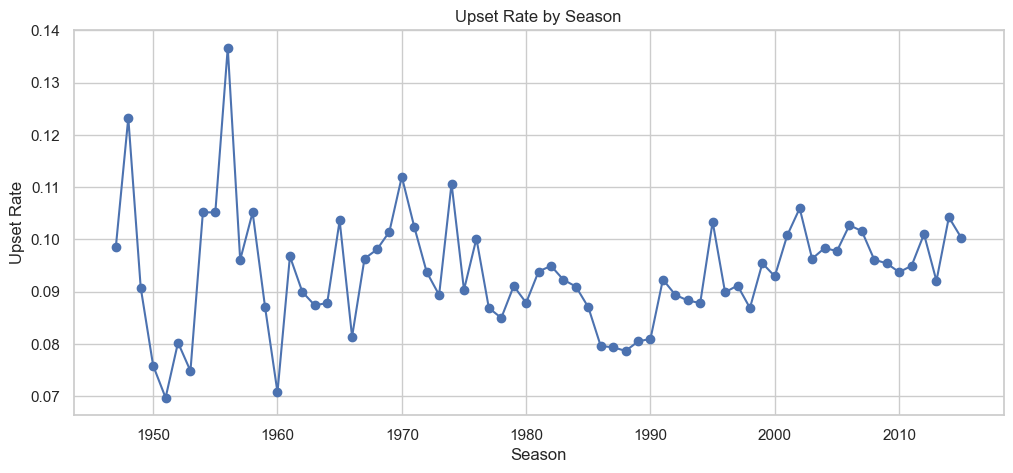

In [17]:
# Upset rate by season
yearly_summary = (
    df.groupby("year_id")
      .agg(
          games=("game_id", "nunique"),
          rows=("game_id", "size"),
          upset_rate=("upset", "mean"),
          avg_forecast=("forecast", "mean"),
          avg_elo_gap=("elo_gap", "mean")
      )
      .reset_index()
)

plt.figure(figsize=(12, 5))
plt.plot(yearly_summary["year_id"], yearly_summary["upset_rate"], marker="o")
plt.title("Upset Rate by Season")
plt.xlabel("Season")
plt.ylabel("Upset Rate")
plt.show()

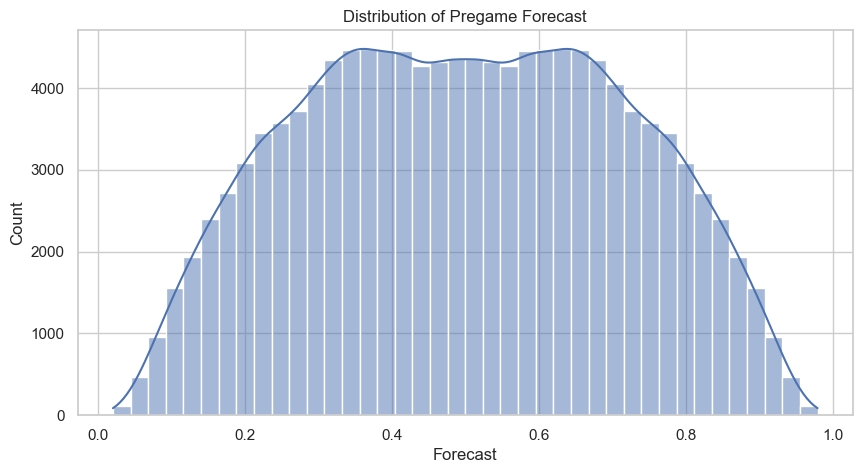

In [18]:
# Forecast distribution
plt.figure(figsize=(10, 5))
sns.histplot(df["forecast"], bins=40, kde=True)
plt.title("Distribution of Pregame Forecast")
plt.xlabel("Forecast")
plt.ylabel("Count")
plt.show()

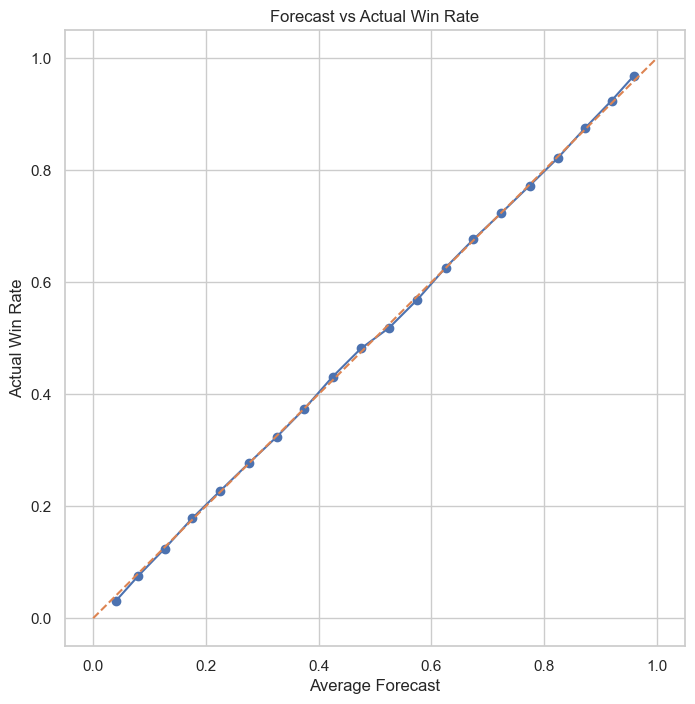

,forecast_bin,avg_forecast,actual_win_rate,count
0,"(-0.001, 0.05]",0.040453,0.031056,161
1,"(0.05, 0.1]",0.080189,0.075741,1822
2,"(0.1, 0.15]",0.126935,0.124368,3956
3,"(0.15, 0.2]",0.176069,0.178735,5662
4,"(0.2, 0.25]",0.225459,0.227375,7094


In [19]:
# Forecast vs actual win rate
forecast_calibration = (
    df.assign(
        forecast_bin=pd.cut(df["forecast"], bins=np.linspace(0, 1, 21), include_lowest=True)
    )
    .groupby("forecast_bin")
    .agg(
        avg_forecast=("forecast", "mean"),
        actual_win_rate=("win", "mean"),
        count=("win", "size")
    )
    .dropna()
    .reset_index()
)

plt.figure(figsize=(8, 8))
plt.plot(forecast_calibration["avg_forecast"], forecast_calibration["actual_win_rate"], marker="o")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Forecast vs Actual Win Rate")
plt.xlabel("Average Forecast")
plt.ylabel("Actual Win Rate")
plt.show()

forecast_calibration.head()

,forecast_bucket,upset_rate,count
0,"(-0.001, 0.2]",0.141971,11601
1,"(0.2, 0.3]",0.253270,15063
2,"(0.3, 0.4]",0.349296,18334
3,"(0.4, 0.5]",0.000000,18159
4,"(0.5, 0.7]",0.000000,36493
5,"(0.7, 1.0]",0.000000,26664


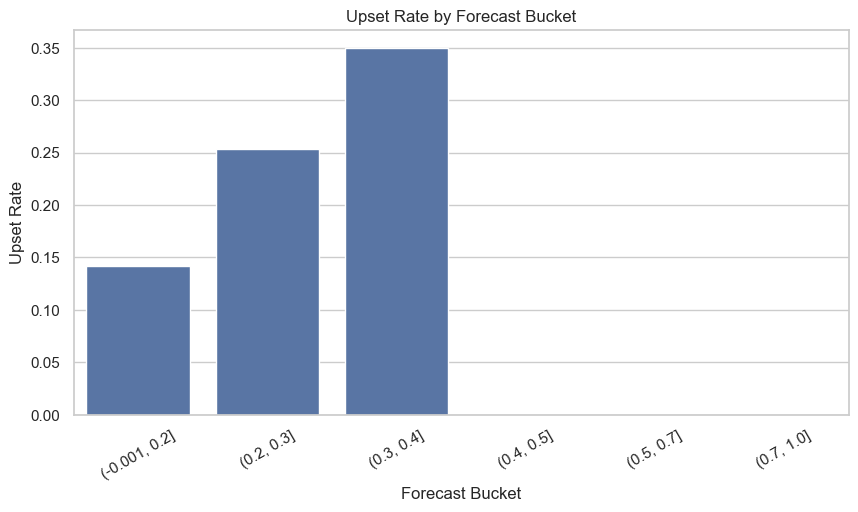

In [20]:
# Upset rate by forecast bucket
df["forecast_bucket"] = pd.cut(
    df["forecast"],
    bins=[0, 0.2, 0.3, 0.4, 0.5, 0.7, 1.0],
    include_lowest=True
)

bucket_summary = (
    df.groupby("forecast_bucket")
      .agg(
          upset_rate=("upset", "mean"),
          count=("upset", "size")
      )
      .reset_index()
)

display(bucket_summary)

plt.figure(figsize=(10, 5))
sns.barplot(data=bucket_summary, x="forecast_bucket", y="upset_rate")
plt.xticks(rotation=30)
plt.title("Upset Rate by Forecast Bucket")
plt.xlabel("Forecast Bucket")
plt.ylabel("Upset Rate")
plt.show()

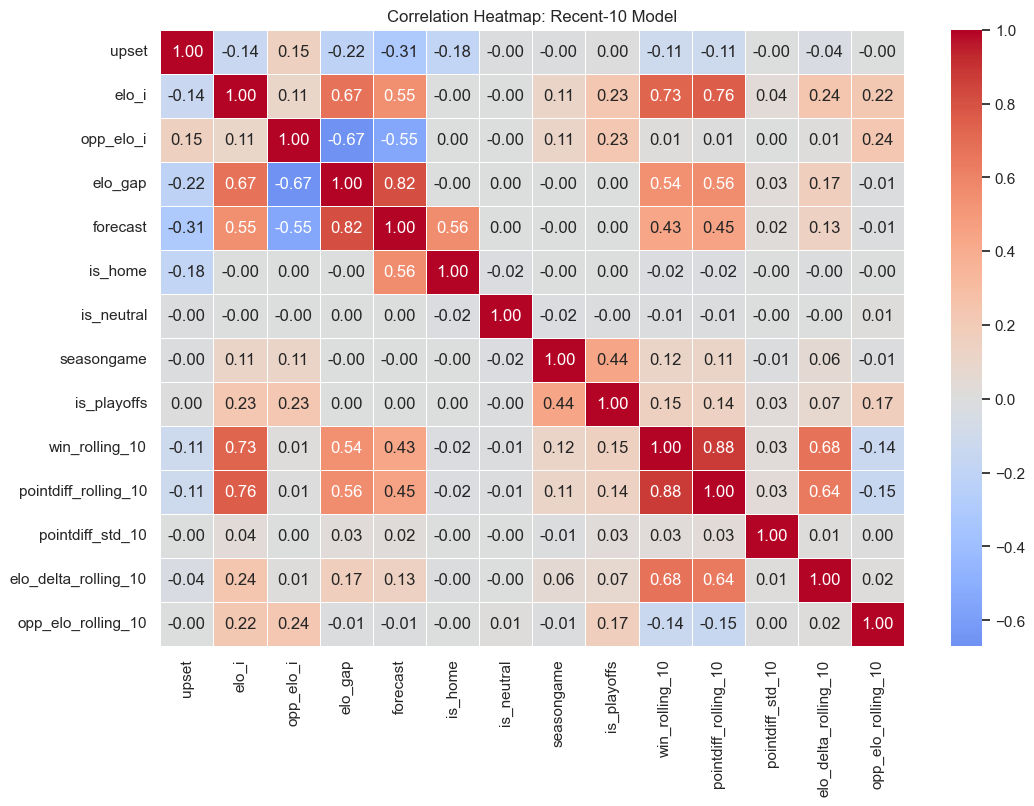

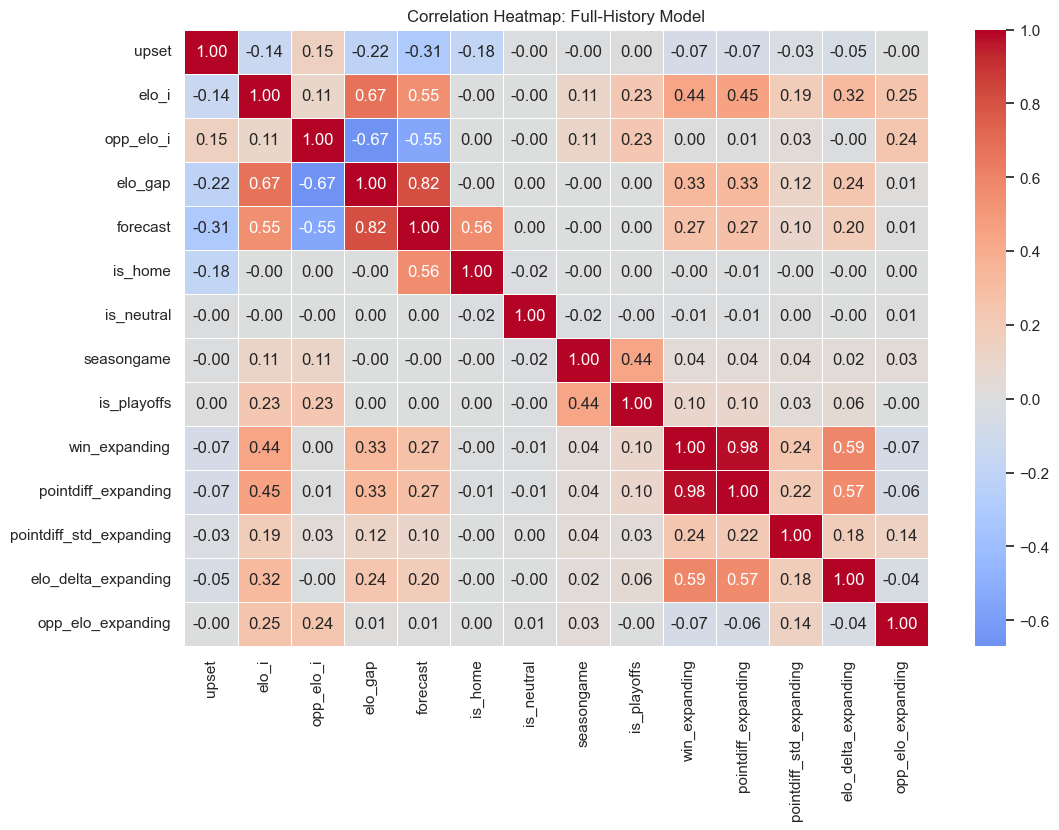

In [21]:
# Correlation heatmaps for each model view
def plot_model_heatmap(data, feature_cols, target_col, title):
    cols = [target_col] + [c for c in feature_cols if c in data.columns]
    corr = data[cols].corr(numeric_only=True)

    plt.figure(figsize=(12, 8))
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        linewidths=0.5
    )
    plt.title(title)
    plt.show()

plot_model_heatmap(
    recent_10_model_df,
    recent_10_model_features,
    "upset",
    "Correlation Heatmap: Recent-10 Model"
)

plot_model_heatmap(
    full_history_model_df,
    full_history_model_features,
    "upset",
    "Correlation Heatmap: Full-History Model"
)

## 7. Chronological split for modeling later

In [22]:
def chronological_train_test_split(data, date_col="date_game", train_frac=0.80):
    data = data.sort_values([date_col, "gameorder", "game_id"]).reset_index(drop=True)
    
    split_idx = int(len(data) * train_frac)
    
    train_df = data.iloc[:split_idx].copy()
    test_df = data.iloc[split_idx:].copy()
    
    return train_df, test_df, split_idx

# Split recent-10 dataframe
recent_10_train_df, recent_10_test_df, recent_10_split_idx = chronological_train_test_split(
    recent_10_model_df,
    date_col="date_game",
    train_frac=0.80
)

# Split full-history dataframe
full_history_train_df, full_history_test_df, full_history_split_idx = chronological_train_test_split(
    full_history_model_df,
    date_col="date_game",
    train_frac=0.80
)

print("RECENT-10 MODEL SPLIT")
print("Train shape:", recent_10_train_df.shape)
print("Test shape:", recent_10_test_df.shape)
print("Train date range:", recent_10_train_df["date_game"].min(), "to", recent_10_train_df["date_game"].max())
print("Test date range:", recent_10_test_df["date_game"].min(), "to", recent_10_test_df["date_game"].max())
print("Train upset rate:", round(recent_10_train_df["upset"].mean(), 4))
print("Test upset rate:", round(recent_10_test_df["upset"].mean(), 4))

print("\nFULL-HISTORY MODEL SPLIT")
print("Train shape:", full_history_train_df.shape)
print("Test shape:", full_history_test_df.shape)
print("Train date range:", full_history_train_df["date_game"].min(), "to", full_history_train_df["date_game"].max())
print("Test date range:", full_history_test_df["date_game"].min(), "to", full_history_test_df["date_game"].max())
print("Train upset rate:", round(full_history_train_df["upset"].mean(), 4))
print("Test upset rate:", round(full_history_test_df["upset"].mean(), 4))

RECENT-10 MODEL SPLIT
Train shape: (101051, 22)
Test shape: (25263, 22)
Train date range: 1946-11-01 00:00:00 to 2005-12-08 00:00:00
Test date range: 2005-12-08 00:00:00 to 2015-06-16 00:00:00
Train upset rate: 0.0929
Test upset rate: 0.0983

FULL-HISTORY MODEL SPLIT
Train shape: (101051, 22)
Test shape: (25263, 22)
Train date range: 1946-11-01 00:00:00 to 2005-12-08 00:00:00
Test date range: 2005-12-08 00:00:00 to 2015-06-16 00:00:00
Train upset rate: 0.0929
Test upset rate: 0.0983
